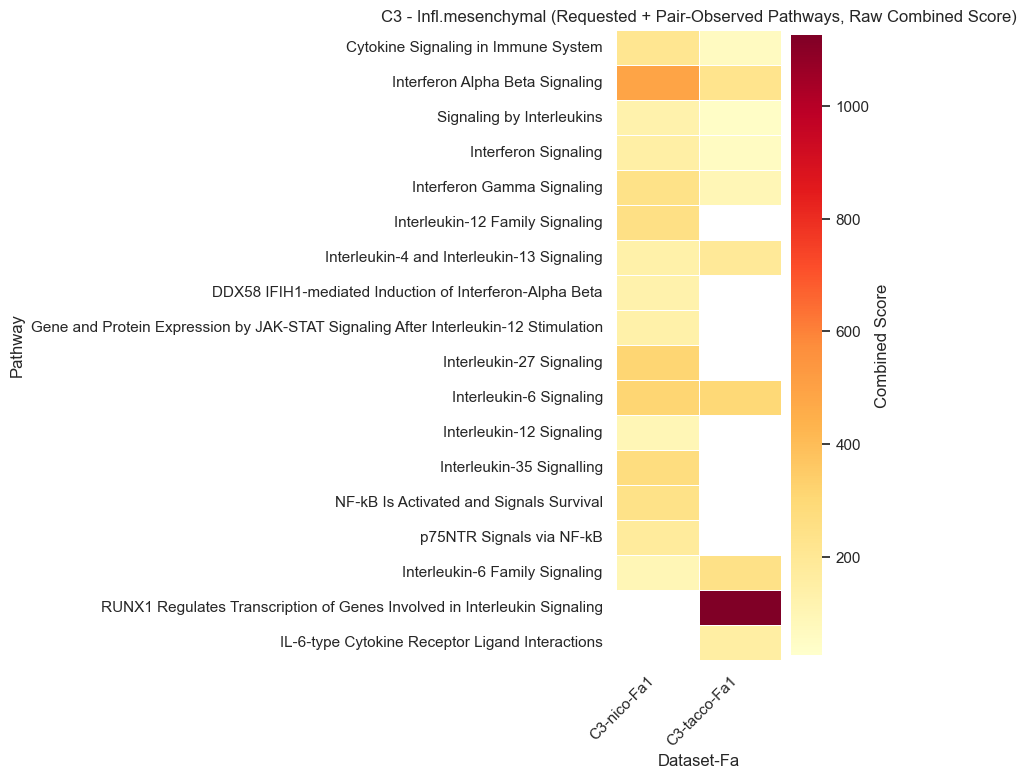

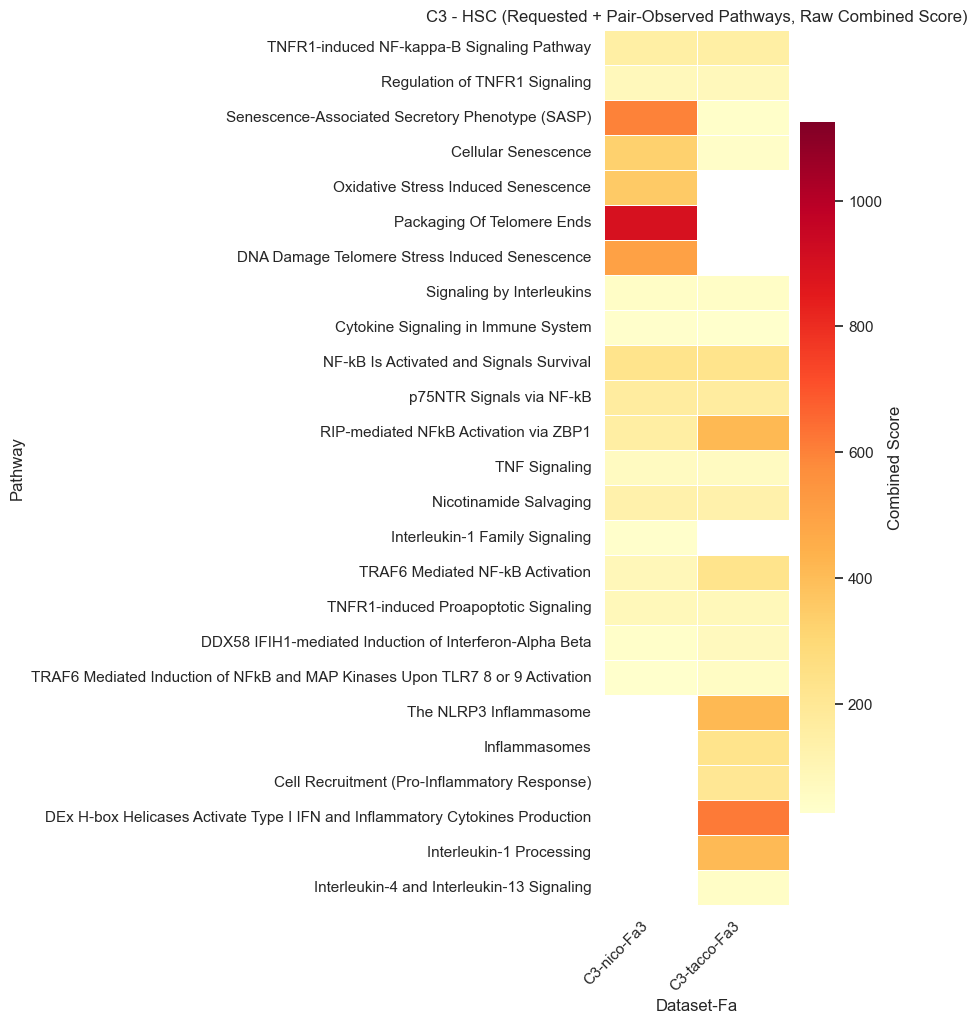

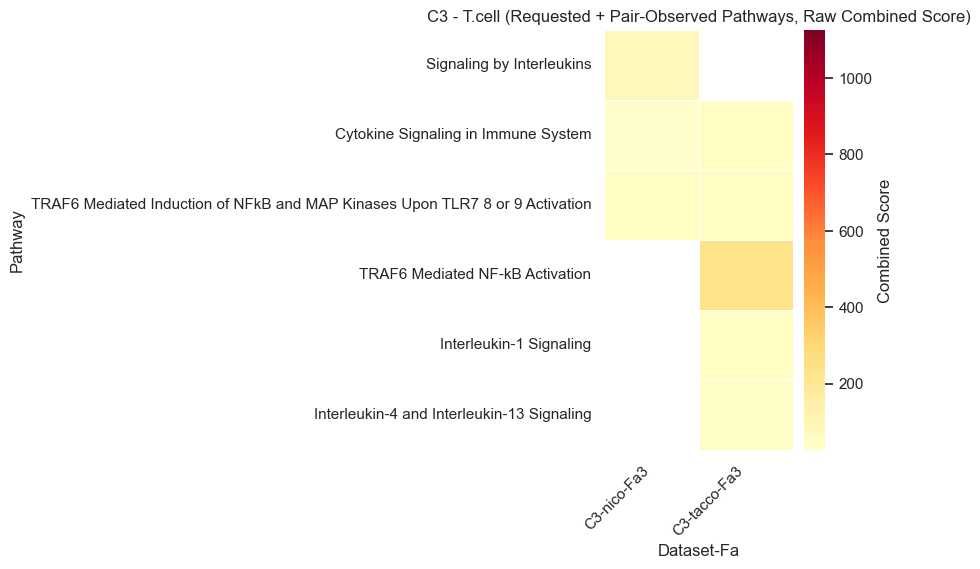

C3: saved 3 single-plot PDFs to /Users/cheung/Documents/Nature_cancer/revision/spatial/C3C4_2024/pathway_heatmap/celltype_raw_single_plot_pdfs


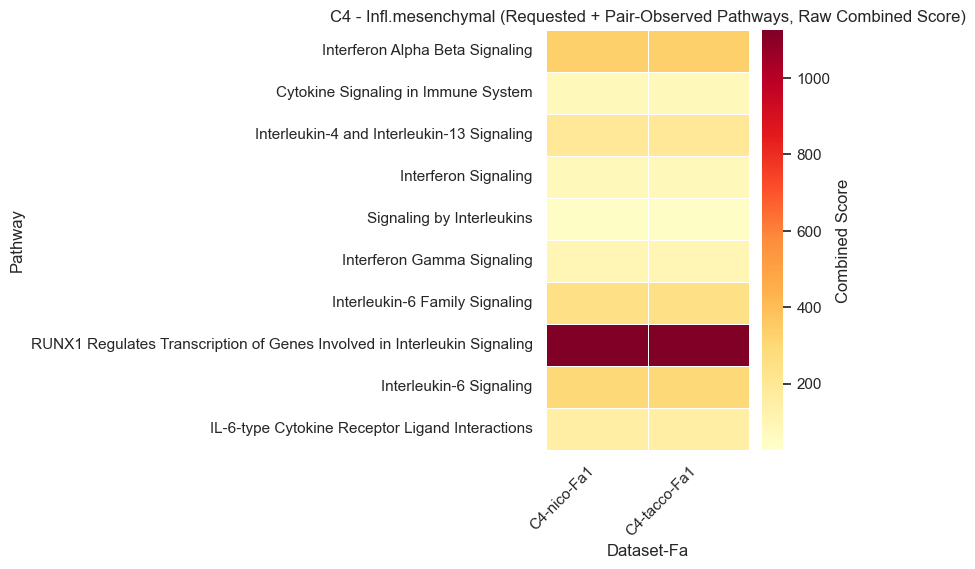

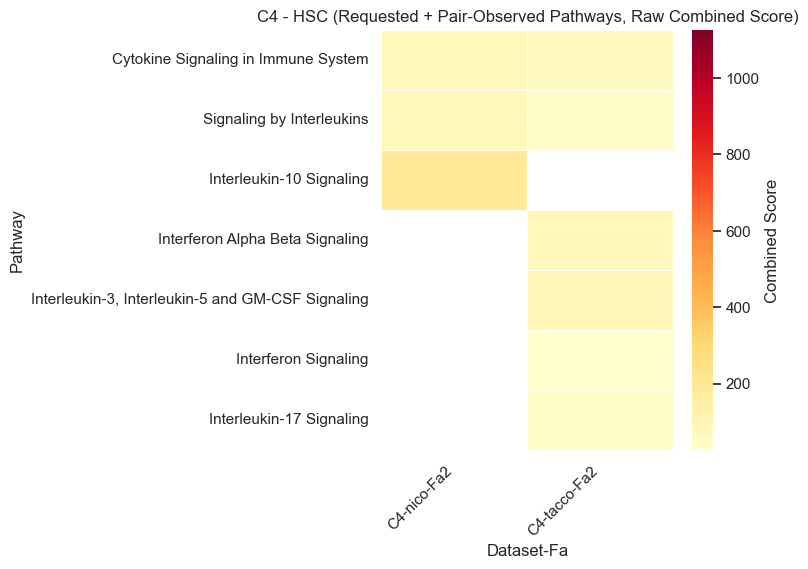

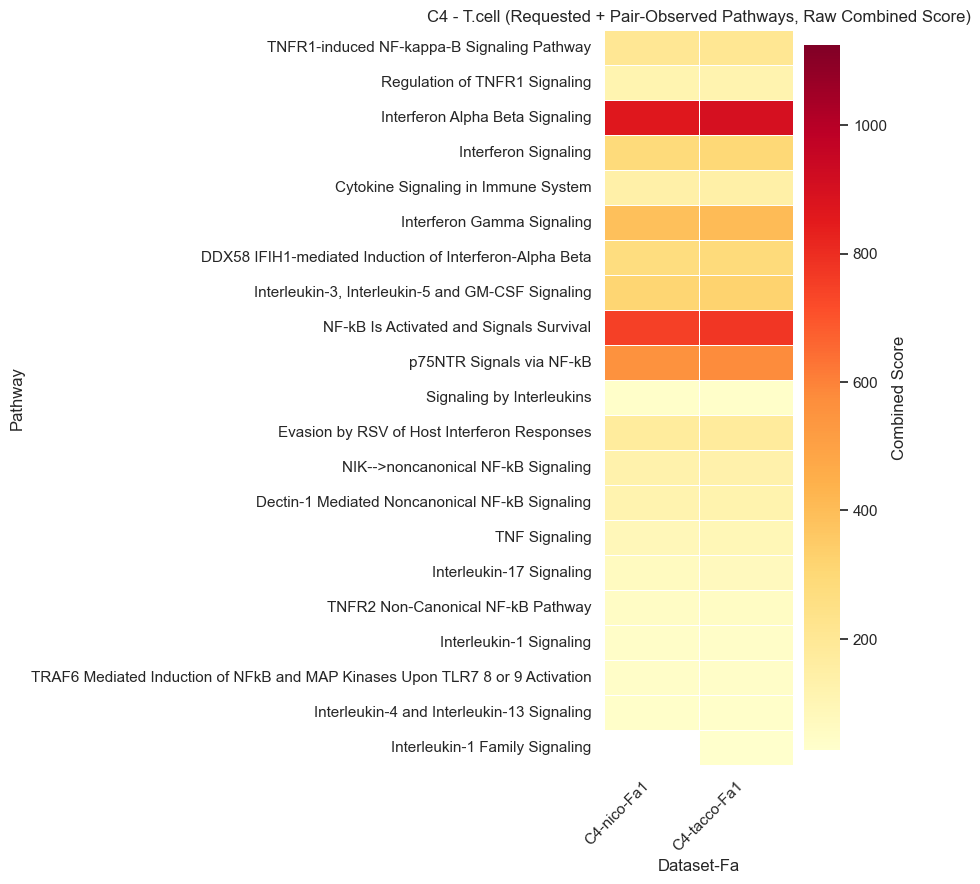

C4: saved 3 single-plot PDFs to /Users/cheung/Documents/Nature_cancer/revision/spatial/C3C4_2024/pathway_heatmap/celltype_raw_single_plot_pdfs
Datasets found: 4
Cell types found: 3
Requested pathways defined: 4
Total PDFs saved: 6


In [ ]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

sns.set_theme(style='white')

search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path('./pathway_heatmap'),
]
for base_dir in search_roots:
    xlsx_files = sorted(base_dir.glob('*.xlsx'))
    if xlsx_files:
        break
else:
    raise FileNotFoundError('No xlsx files found in the heatmap folder.')

requested_pathways = [
    'TNFR1-induced NF-kappa-B Signaling Pathway',
    'Regulation of TNFR1 Signaling',
    'Senescence-Associated Secretory Phenotype (SASP)',
    'Cellular Senescence',
]


def load_enrichment_table(xlsx_path: Path) -> pd.DataFrame:
    workbook = pd.ExcelFile(xlsx_path)
    tables = []
    for sheet_name in workbook.sheet_names:
        table = workbook.parse(sheet_name)
        if table.empty:
            continue
        table = table.copy()
        table.columns = [str(col).strip() for col in table.columns]
        required = {'Dataset', 'CellType', 'Factor', 'Term', 'Combined Score'}
        missing = required.difference(table.columns)
        if missing:
            raise ValueError(f'{xlsx_path.name} / {sheet_name}: missing columns {sorted(missing)}')
        table['Source file'] = xlsx_path.stem
        table['Sheet'] = sheet_name
        tables.append(table)
    if not tables:
        return pd.DataFrame()
    return pd.concat(tables, ignore_index=True)


def short_dataset_name(dataset: str) -> str:
    parts = str(dataset).split('_')
    if len(parts) >= 2:
        source = parts[1]
        if source == 'taccor':
            source = 'tacco'
        return f'{parts[0]}-{source}'
    return str(dataset)


all_tables = [load_enrichment_table(path) for path in xlsx_files]
all_tables = [table for table in all_tables if not table.empty]
if not all_tables:
    raise ValueError('No enrichment rows were found in the xlsx files.')


df = pd.concat(all_tables, ignore_index=True)
df['Combined Score'] = pd.to_numeric(df['Combined Score'], errors='coerce')
df = df.dropna(subset=['CellType', 'Dataset', 'Factor', 'Term', 'Combined Score']).copy()
df['Dataset-Factor'] = df['Dataset'].astype(str) + '-' + df['Factor'].astype(str)

vmin = df['Combined Score'].min()
vmax = df['Combined Score'].max()

output_dir = base_dir / 'celltype_raw_single_plot_pdfs'
output_dir.mkdir(parents=True, exist_ok=True)
saved_files = []

for cohort in ['C3', 'C4']:
    cohort_df = df.loc[df['Dataset'].astype(str).str.startswith(cohort)].copy()
    if cohort_df.empty:
        print(f'{cohort}: no datasets found')
        continue

    dataset_factor_order = sorted(cohort_df['Dataset-Factor'].astype(str).unique())
    dataset_factor_label_map = {
        key: f"{short_dataset_name(key.split('-', 1)[0])}-{key.split('-', 1)[1]}"
        for key in dataset_factor_order
    }
    cell_types = [cell_type for cell_type in cohort_df['CellType'].dropna().drop_duplicates().tolist()]
    if not cell_types:
        print(f'{cohort}: no cell types found')
        continue

    plots_made = 0
    for cell_type in cell_types:
        sub = cohort_df.loc[cohort_df['CellType'] == cell_type].copy()
        if sub.empty:
            continue

        pair_pathways = sub['Term'].dropna().drop_duplicates().tolist()
        combined_pathways = list(dict.fromkeys(requested_pathways + pair_pathways))
        combined_df = sub.loc[sub['Term'].isin(combined_pathways)].copy()
        if combined_df.empty:
            print(f'{cohort} / {cell_type}: no pathways found in this dataset pair')
            continue

        score_matrix = (
            combined_df.groupby(['Term', 'Dataset-Factor'])['Combined Score']
            .max()
            .unstack('Dataset-Factor')
            .reindex(index=combined_pathways, columns=dataset_factor_order)
        )
        score_matrix = score_matrix.dropna(how='all').dropna(axis=1, how='all')
        if score_matrix.empty:
            print(f'{cohort} / {cell_type}: empty score matrix after reindexing')
            continue

        fig_raw, ax_raw = plt.subplots(
            figsize=(max(8, score_matrix.shape[1] * 1.2), max(6, score_matrix.shape[0] * 0.5))
        )
        sns.heatmap(
            score_matrix,
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Combined Score'},
            ax=ax_raw,
            vmin=vmin,
            vmax=vmax,
        )
        ax_raw.set_title(f'{cohort} - {cell_type} (Requested + Pair-Observed Pathways, Raw Combined Score)')
        ax_raw.set_xlabel('Dataset-Fa')
        ax_raw.set_ylabel('Pathway')
        short_xticklabels = [dataset_factor_label_map.get(label.get_text(), label.get_text()) for label in ax_raw.get_xticklabels()]
        ax_raw.set_xticklabels(short_xticklabels, rotation=45, ha='right')
        ax_raw.set_yticklabels(ax_raw.get_yticklabels(), rotation=0)

        max_term_len = max(len(str(term)) for term in score_matrix.index) if len(score_matrix.index) > 0 else 20
        left_margin = min(0.72, max(0.34, 0.006 * max_term_len + 0.18))
        fig_raw.subplots_adjust(left=left_margin, bottom=0.22, right=0.93, top=0.92)
        fig_raw.canvas.draw()

        safe_cell_type = ''.join(ch if ch.isalnum() or ch in {'-', '_'} else '_' for ch in str(cell_type))
        output_pdf = output_dir / f'{cohort}_{safe_cell_type}_pathway_raw_heatmap.pdf'
        fig_raw.savefig(output_pdf, format='pdf', bbox_inches='tight', pad_inches=0.25)
        saved_files.append(output_pdf)

        plt.show()
        plt.close(fig_raw)
        plots_made += 1

    print(f'{cohort}: saved {plots_made} single-plot PDFs to {output_dir}')

print(f'Datasets found: {df["Dataset"].nunique()}')
print(f'Cell types found: {df["CellType"].nunique()}')
print(f'Requested pathways defined: {len(requested_pathways)}')
print(f'Total PDFs saved: {len(saved_files)}')